In [39]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integ

In [40]:
gamma = 10
t = 5
W = np.random.normal(0,np.sqrt(t),size=10000)
X = np.sqrt(gamma)*np.random.normal(0,np.sqrt(t/gamma),size=10000)


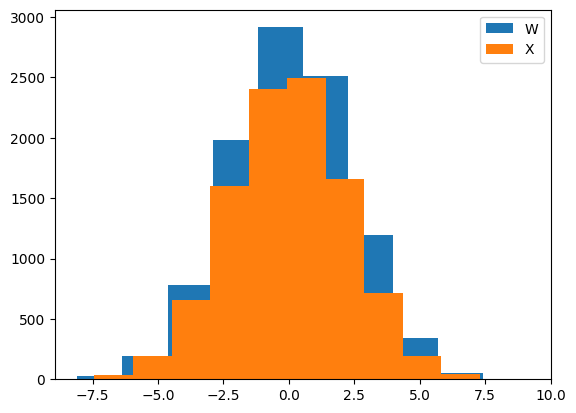

In [41]:
plt.hist(W,label="W")
plt.hist(X,label="X")
plt.legend()

plt.show()

In [42]:
t = 10; u = 5
Z = np.random.normal(0,1,100_000)
X_t = np.sqrt(t)*Z
X_tu = np.sqrt(t+u)*Z
print(np.var(X_tu-X_t))
print((np.sqrt(t+u)-np.sqrt(t))**2)





0.5055322586365034
0.505102572168219


### Problem 6

1. Simulate three Brownian motion paths on $t\in[0,1]$
2. Simulate two correlated Brownian motion paths with a user specified correlation $\rho$ on $t\in[0,1]$


In [43]:
def brownian_gen(start,end,N,d):
    path = np.zeros(shape=(N+1,d))
    path[0,:] = 0
    for i in range(1,N+1):
        path[i] = path[i-1]+np.random.normal(loc=0,scale=np.sqrt((end-start)/N),size=d)

    return np.linspace(start=start,stop=end,num=N+1),path

def cBrownian_gen(start,end,N,rho):
    path = np.zeros(shape=(N+1,2))
    path[0,:] = 0
    t,W = brownian_gen(start=start,end=end,N=N,d=1)
    path[:,0] = W.reshape((N+1,))
    for i in range(1,N+1):
        path[i,1] = np.sqrt(1-rho**2)*(path[i-1,1]+np.random.normal(loc=0,scale=np.sqrt((end-start)/N)))
    path[:,1] += rho*path[:,0]
    return t,path

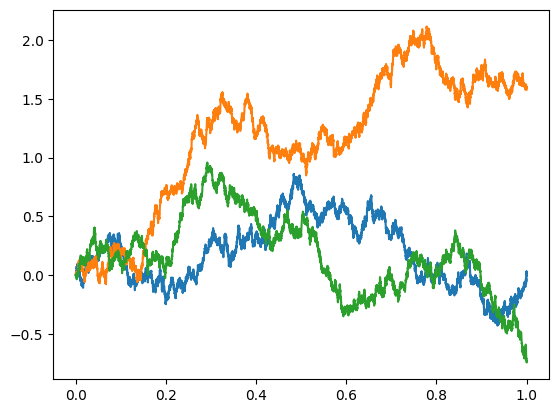

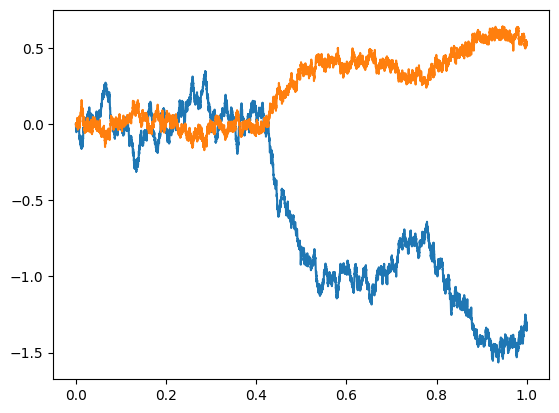

In [44]:
t,W = brownian_gen(0,1,10_000,3)
plt.plot(t,W)
plt.show()

t2,Wc = cBrownian_gen(0,1,10_000,-0.4)
plt.plot(t2,Wc)
plt.show()

### Problem 8
Consider a Brownian motion path that passes through two gates situated at times
$t_1$ and $t_2$.
1. Derive the expected value of $W_{t_1}$ of all paths that pass through gate 1.
2. Derive the expected value of $W_{t_2}$ of all paths that pass through gate 1 and
gate 2.
3. Derive an expression for the expected value of the increment over time
interval $[t_1,t_2]$ for paths that pass through both gates.
4. Design a simulation program for Brownian motion through gates, and verify
the answers to (1), (2), and (3) by simulation.

Let $\mathcal{G}_1 = [a_1,b_1]$ and let $\mathcal{G}_2 = [a_2,b_2]$, and $W_t \sim \mathcal{N}(0,t)$ hence $Z_t = W_t/\sqrt{t} \sim \mathcal{N}(0,1)$

**1**
$$
\mathbb{E}[W_{t_1}|W_{t_1}\in \mathcal{G}_1] = \frac{\int^{b_1}_{a_1} z \frac{1}{\sqrt{2\pi t_1}}\exp(-\frac{z^2}{2 t_1}) dz}{\Phi(b_1/\sqrt{t_1})-\Phi(a_1/\sqrt{t_1})} = -\frac{\int^{-b_1^2/2t_1}_{-a_1^2/2t_1}\frac{\sqrt{t_1}}{\sqrt{2\pi}}\exp(u) du}{\Phi(b_1/\sqrt{t_1})-\Phi(a_1/\sqrt{t_1})} = \frac{\frac{\sqrt{t_1}}{\sqrt{2\pi}}\left(\exp(-a_1^2/2t_1)-\exp(-b_1^2/2t_1)\right)}{\Phi(b_1/\sqrt{t_1})-\Phi(a_1/\sqrt{t_1})}
$$



**2**

$$
\mathbb{E}[W_{t_2}|W_{t_2} \in \mathcal{G}_2 , W_{t_1} \in \mathcal{G}_1] = \frac{\int^{b_2}_{a_2}\int^{b_1}_{a_1}  z_2 f_{Z_1,Z_2}(z_1,z_2) dz_1 dz_2}{\mathbb{P}(W_{t_2}\in \mathcal{G}_2 , W_{t_1} \in \mathcal{G}_1)}
$$

and with $\text{Cov}(W_{t_2},W_{t_1}) = t_1$, hence $\Sigma = \begin{pmatrix} t_1 & t_1 \\ t_1 & t_2 \end{pmatrix}$ and $\text{det}(\Sigma) = t_1t_2-t_1^2$, and $\Sigma^{-1} = \frac{1}{\text{det}(\Sigma)}\begin{pmatrix} t_2 & -t_1 \\ -t_1 & t_1\end{pmatrix}$
$$f_{Z_1,Z_2}(z_1,z_2) = \frac{1}{2\pi \sqrt{\text{det}(\Sigma)}} \exp \left(-\frac{1}{2} Z^T \Sigma^{-1} Z \right)$$

**3**

$$
\mathbb{E}[W_{t_2}-W_{t_1}|W_{t_2} \in \mathcal{G}_2 , W_{t_1} \in \mathcal{G}_1] = \frac{\int^{b_2}_{a_2}\int^{b_1}_{a_1}  (z_2-z_1) f_{Z_1,Z_2}(z_1,z_2) dz_1 dz_2}{\mathbb{P}(W_{t_2}\in \mathcal{G}_2 , W_{t_1} \in \mathcal{G}_1)}
$$

In [45]:
t_1 = 1
a_1 = 0
b_1 = 0.4
t_2 = 4
a_2 = 0
b_2 = 0.7

In [46]:
def theor1(a_1,b_1,t_1):
    upper =(np.sqrt(t_1)/np.sqrt(2*np.pi)) * (np.exp(-a_1**2/(2*t_1)) -np.exp(-b_1**2/(2*t_1) ))
    lower = stats.norm.cdf(b_1/np.sqrt(t_1))-stats.norm.cdf(a_1/np.sqrt(t_1))
    return upper/lower

def theor2(a_1,a_2,b_1,b_2,t_1,t_2):
    Sigma = [[t_1,t_1],[t_1,t_2]]
    mvn = stats.multivariate_normal([0,0],Sigma)
    upper,_ = integ.dblquad(lambda z_2,z_1 : z_2 *mvn.pdf([z_1,z_2]),a_1,b_1,a_2,b_2)
    lower,_ = integ.dblquad(lambda z_2,z_1 : mvn.pdf([z_1,z_2]),a_1,b_1,a_2,b_2)
    return upper/lower


def theor3(a_1,a_2,b_1,b_2,t_1,t_2):
    Sigma = [[t_1,t_1],[t_1,t_2]]
    mvn = stats.multivariate_normal([0,0],Sigma)
    upper,_ = integ.dblquad(lambda z_2,z_1 : (z_2-z_1) *mvn.pdf([z_1,z_2]),a_1,b_1,a_2,b_2)
    lower,_ = integ.dblquad(lambda z_2,z_1 : mvn.pdf([z_1,z_2]),a_1,b_1,a_2,b_2)
    return upper/lower


In [47]:
def gate(W,t_vec,a,b,t):
    t_index = np.where(t_vec == t)[0][0]
    row = W[t_index, :]
    return t_index,np.where((row >= a) & (row <= b))[0]

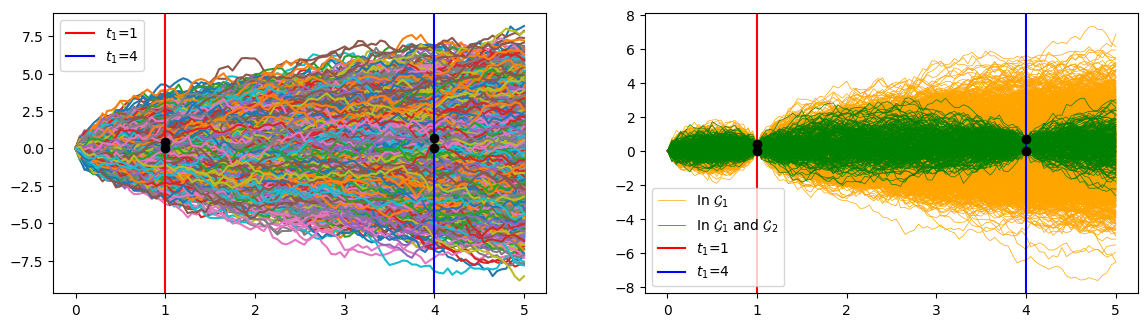

In [48]:
plt.figure(figsize=(14,8))

t_vec,W_paths = brownian_gen(start=0,end=5,N=100,d=10000)
plt.subplot(2,2,1)
plt.plot(t_vec,W_paths)
# gate 1

t1_index,W_g1 = gate(W_paths,t_vec,a_1,b_1,t_1)
plt.axvline(t_1,label=fr"$t_1$={t_1}",color="red")
plt.plot(t_1,a_1,'o',markersize=6,color='black')
plt.plot(t_1,b_1,'o',markersize=6,color='black')
# gate 2

t2_index,W_g2 = gate(W_paths,t_vec,a_2,b_2,t_2)
plt.axvline(t_2,label=fr"$t_1$={t_2}",color="blue")
plt.plot(t_2,a_2,'o',markersize=6,color='black')
plt.plot(t_2,b_2,'o',markersize=6,color='black')


plt.legend()

plt.subplot(2,2,2)
lines1 = plt.plot(t_vec, W_paths[:, np.setdiff1d(W_g1, W_g2)],color="orange",lw=0.5)
lines1[0].set_label(fr"In $\mathcal{{G}}_1$")

lines2 = plt.plot(t_vec, W_paths[:, np.intersect1d(W_g1, W_g2)],color="green",lw=0.5)
lines2[0].set_label(fr"In $\mathcal{{G}}_1$ and $\mathcal{{G}}_2$")

plt.axvline(t_1,label=fr"$t_1$={t_1}",color="red")
plt.plot(t_1,a_1,'o',markersize=6,color='black')
plt.plot(t_1,b_1,'o',markersize=6,color='black')
plt.axvline(t_2,label=fr"$t_1$={t_2}",color="blue")
plt.plot(t_2,a_2,'o',markersize=6,color='black')
plt.plot(t_2,b_2,'o',markersize=6,color='black')
plt.legend()
plt.show()

In [49]:

# 1.
print("---- 1. ----\n")
print(f"Empirical : {np.mean(W_paths[t1_index,W_g1])}")
print(f"Theoretical : {theor1(a_1,b_1,t_1)}")
# 2.
print("---- 2. ----\n")
print(f"Empirical : {np.mean(W_paths[t2_index,np.intersect1d(W_g1, W_g2)])}")
print(f"Theoretical : {theor2(a_1,a_2,b_1,b_2,t_1,t_2)}")

# 3.
print("---- 3. ----\n")
print(f"Empirical : {np.mean(W_paths[t2_index,np.intersect1d(W_g1, W_g2)]-W_paths[t1_index,np.intersect1d(W_g1, W_g2)])}")
print(f"Theoretical : {theor3(a_1,a_2,b_1,b_2,t_1,t_2)}")


---- 1. ----

Empirical : 0.2017891681367895
Theoretical : 0.1973478084875091
---- 2. ----

Empirical : 0.3521059997706872
Theoretical : 0.3479425404995197
---- 3. ----

Empirical : 0.15805128760729317
Theoretical : 0.14993724382639825


### Problem 9

In [144]:
v = 2.5
def symmetric_Rwlk(T,N,d):
    dt = T/N
    X = np.zeros(shape=(N+1,d))
    for i in range(1,N+1):
        X[i,:] = X[i-1,:]+np.sqrt(dt)*np.random.standard_t(df=v,size=d)

    return np.linspace(0,stop=1,num=N+1),X

In [145]:
s1,W10 = symmetric_Rwlk(1,10,1000)
s2,W10k = symmetric_Rwlk(1,10_000,1000)
s3,W100k = symmetric_Rwlk(1,100_000,1000)

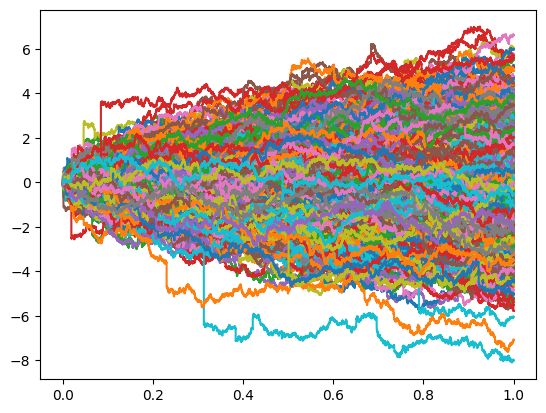

In [149]:
plt.plot(s2,W10k)
plt.show()


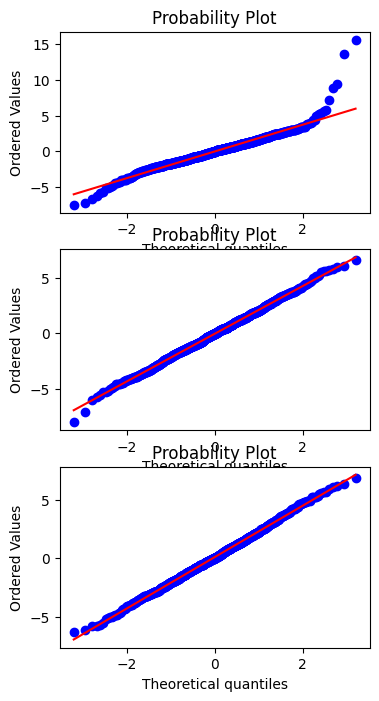

-0.04388865164566779 3.7429137477095593
-0.04111906579094457 4.614170265028206
0.09092849508545266 4.806069205721293
5.0


In [147]:
plt.figure(figsize=(4,8))

plt.subplot(3,1,1)
stats.probplot(W10[-1,:],dist="norm",plot=plt)
plt.subplot(3,1,2)

stats.probplot(W10k[-1,:],dist="norm",plot=plt)
plt.subplot(3,1,3)

stats.probplot(W100k[-1,:],dist="norm",plot=plt)

plt.show()
print(np.mean(W10[-1,:]),np.var(W10[-1,:])) # roughly (0,v/(v-2))
print(np.mean(W10k[-1,:]),np.var(W10k[-1,:])) # roughly (0,v/(v-2))
print(np.mean(W100k[-1,:]),np.var(W100k[-1,:])) # roughly (0,v/(v-2))

print(v/(v-2))

### Problem 10


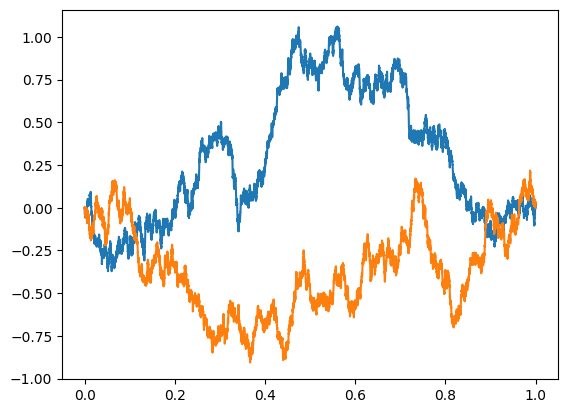

In [172]:
s, W1 = brownian_gen(0,1,10_000,d=2)
X = np.zeros(shape=(10_000+1,2))
t__ = np.linspace(0,1,num=10_000+1)
for i in range(1,len(s)):
    X[i,:] = W1[i,:]-t__[i]*W1[-1,:]

plt.plot(s,X)
plt.show()